In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

ZIP_FILE = Path(
    "/content/drive/MyDrive/MachineLearningCSV.zip"
)

print("ZIP exists:", ZIP_FILE.exists())
print("ZIP path:", ZIP_FILE)

ZIP exists: True
ZIP path: /content/drive/MyDrive/MachineLearningCSV.zip


In [ ]:
import zipfile
from pathlib import Path

ZIP_FILE = Path("/content/drive/MyDrive/MachineLearningCSV.zip")
EXTRACT_DIR = Path("/content/CIC-IDS2017")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction completed!")

Extraction completed!


In [ ]:
csv_files = sorted(EXTRACT_DIR.rglob("*.csv"))

print("CSV files found:", len(csv_files))

for file in csv_files:
    print(file)

CSV files found: 8
/content/CIC-IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/content/CIC-IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/content/CIC-IDS2017/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
/content/CIC-IDS2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
/content/CIC-IDS2017/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/content/CIC-IDS2017/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/content/CIC-IDS2017/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
/content/CIC-IDS2017/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
!pip install -q pandas numpy scikit-learn pyarrow networkx

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# Dataset location
EXTRACT_DIR = Path("/content/CIC-IDS2017")

# Output location in Google Drive
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN"
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Find all CSV files
csv_files = sorted(
    EXTRACT_DIR.rglob("*.csv")
)

print("CSV files found:", len(csv_files))

for f in csv_files:
    print("-", f.name)

print("\nProcessed data will be saved to:")
print(PROCESSED_DIR)

CSV files found: 8
- Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
- Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
- Friday-WorkingHours-Morning.pcap_ISCX.csv
- Monday-WorkingHours.pcap_ISCX.csv
- Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
- Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
- Tuesday-WorkingHours.pcap_ISCX.csv
- Wednesday-workingHours.pcap_ISCX.csv

Processed data will be saved to:
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed


In [ ]:
GRAPH_FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "Average Packet Size",
    "Destination Port",
    "Protocol"
]

In [ ]:
# Columns required for graph construction
REQUIRED_COLUMNS = [
    "Source IP",
    "Destination IP",
    "Label"
]

print("Number of selected network features:", len(GRAPH_FEATURES))

Number of selected network features: 19


In [ ]:
for file in csv_files:

    sample = pd.read_csv(
        file,
        nrows=2,
        low_memory=False
    )

    sample.columns = (
        sample.columns
        .str.strip()
    )

    missing = [
        col
        for col in REQUIRED_COLUMNS + GRAPH_FEATURES
        if col not in sample.columns
    ]

    print("\n", file.name)

    if missing:
        print("Missing columns:", missing)
    else:
        print("All required columns found ✓")


 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Missing columns: ['Source IP', 'Destination IP', 'Protocol']

 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Missing columns: ['Source IP', 'Destination IP', 'Protocol']

 Friday-WorkingHours-Morning.pcap_ISCX.csv
Missing columns: ['Source IP', 'Destination IP', 'Protocol']

 Monday-WorkingHours.pcap_ISCX.csv
Missing columns: ['Source IP', 'Destination IP', 'Protocol']

 Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Missing columns: ['Source IP', 'Destination IP', 'Protocol']

 Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Missing columns: ['Source IP', 'Destination IP', 'Protocol']

 Tuesday-WorkingHours.pcap_ISCX.csv
Missing columns: ['Source IP', 'Destination IP', 'Protocol']

 Wednesday-workingHours.pcap_ISCX.csv
Missing columns: ['Source IP', 'Destination IP', 'Protocol']


In [ ]:
import pandas as pd

test_file = csv_files[0]

df_test = pd.read_csv(
    test_file,
    nrows=2,
    low_memory=False
)

print("FILE:")
print(test_file)

print("\nNUMBER OF COLUMNS:")
print(len(df_test.columns))

print("\nEXACT COLUMN NAMES:")
for i, col in enumerate(df_test.columns):
    print(i, repr(col))

FILE:
/content/CIC-IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

NUMBER OF COLUMNS:
79

EXACT COLUMN NAMES:
0 ' Destination Port'
1 ' Flow Duration'
2 ' Total Fwd Packets'
3 ' Total Backward Packets'
4 'Total Length of Fwd Packets'
5 ' Total Length of Bwd Packets'
6 ' Fwd Packet Length Max'
7 ' Fwd Packet Length Min'
8 ' Fwd Packet Length Mean'
9 ' Fwd Packet Length Std'
10 'Bwd Packet Length Max'
11 ' Bwd Packet Length Min'
12 ' Bwd Packet Length Mean'
13 ' Bwd Packet Length Std'
14 'Flow Bytes/s'
15 ' Flow Packets/s'
16 ' Flow IAT Mean'
17 ' Flow IAT Std'
18 ' Flow IAT Max'
19 ' Flow IAT Min'
20 'Fwd IAT Total'
21 ' Fwd IAT Mean'
22 ' Fwd IAT Std'
23 ' Fwd IAT Max'
24 ' Fwd IAT Min'
25 'Bwd IAT Total'
26 ' Bwd IAT Mean'
27 ' Bwd IAT Std'
28 ' Bwd IAT Max'
29 ' Bwd IAT Min'
30 'Fwd PSH Flags'
31 ' Bwd PSH Flags'
32 ' Fwd URG Flags'
33 ' Bwd URG Flags'
34 ' Fwd Header Length'
35 ' Bwd Header Length'
36 'Fwd Packets/s'
37 ' Bwd Packets/s'
38 ' Min Packet L

In [ ]:
print("\nFIRST 5 ROWS:")
display(df_test.head())


FIRST 5 ROWS:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6,0,...,20,0,0,0,0,0,0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6,0,...,20,0,0,0,0,0,0,0,0,BENIGN


In [ ]:
from pathlib import Path

ZIP_FILE = Path(
    "/content/drive/MyDrive/GeneratedLabelledFlows.zip"
)

print("ZIP exists:", ZIP_FILE.exists())

if ZIP_FILE.exists():
    print("Size (MB):", round(ZIP_FILE.stat().st_size / (1024**2), 2))

ZIP exists: True
Size (MB): 270.73


In [ ]:
import zipfile
from pathlib import Path

EXTRACT_DIR = Path("/content/GeneratedLabelledFlows")

EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction completed!")

Extraction completed!


In [ ]:
csv_files = sorted(
    EXTRACT_DIR.rglob("*.csv")
)

print("CSV files found:", len(csv_files))

for file in csv_files:
    print("-", file)

CSV files found: 8
- /content/GeneratedLabelledFlows/TrafficLabelling /Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
- /content/GeneratedLabelledFlows/TrafficLabelling /Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
- /content/GeneratedLabelledFlows/TrafficLabelling /Friday-WorkingHours-Morning.pcap_ISCX.csv
- /content/GeneratedLabelledFlows/TrafficLabelling /Monday-WorkingHours.pcap_ISCX.csv
- /content/GeneratedLabelledFlows/TrafficLabelling /Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
- /content/GeneratedLabelledFlows/TrafficLabelling /Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
- /content/GeneratedLabelledFlows/TrafficLabelling /Tuesday-WorkingHours.pcap_ISCX.csv
- /content/GeneratedLabelledFlows/TrafficLabelling /Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
import pandas as pd

test_file = csv_files[0]

df_test = pd.read_csv(
    test_file,
    nrows=5,
    low_memory=False
)

df_test.columns = (
    df_test.columns
    .str.strip()
)

print("File:", test_file.name)
print("Columns:", len(df_test.columns))

print("\nCOLUMN NAMES:")
for i, col in enumerate(df_test.columns):
    print(i, repr(col))

File: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Columns: 85

COLUMN NAMES:
0 'Flow ID'
1 'Source IP'
2 'Source Port'
3 'Destination IP'
4 'Destination Port'
5 'Protocol'
6 'Timestamp'
7 'Flow Duration'
8 'Total Fwd Packets'
9 'Total Backward Packets'
10 'Total Length of Fwd Packets'
11 'Total Length of Bwd Packets'
12 'Fwd Packet Length Max'
13 'Fwd Packet Length Min'
14 'Fwd Packet Length Mean'
15 'Fwd Packet Length Std'
16 'Bwd Packet Length Max'
17 'Bwd Packet Length Min'
18 'Bwd Packet Length Mean'
19 'Bwd Packet Length Std'
20 'Flow Bytes/s'
21 'Flow Packets/s'
22 'Flow IAT Mean'
23 'Flow IAT Std'
24 'Flow IAT Max'
25 'Flow IAT Min'
26 'Fwd IAT Total'
27 'Fwd IAT Mean'
28 'Fwd IAT Std'
29 'Fwd IAT Max'
30 'Fwd IAT Min'
31 'Bwd IAT Total'
32 'Bwd IAT Mean'
33 'Bwd IAT Std'
34 'Bwd IAT Max'
35 'Bwd IAT Min'
36 'Fwd PSH Flags'
37 'Bwd PSH Flags'
38 'Fwd URG Flags'
39 'Bwd URG Flags'
40 'Fwd Header Length'
41 'Bwd Header Length'
42 'Fwd Packets/s'
43 'Bwd Packets/s'
44 'Min Pac

In [ ]:
display(df_test.head())

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0,0,0,0,0,0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0,0,0,0,0,0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0,0,0,0,0,0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0,0,0,0,0,0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0,0,0,0,0,0,0,0,BENIGN


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import gc

# ============================================================
# PATHS
# ============================================================

EXTRACT_DIR = Path("/content/GeneratedLabelledFlows")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN"
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# FIND CSV FILES
# ============================================================

csv_files = sorted(
    EXTRACT_DIR.rglob("*.csv")
)

print("=" * 70)
print("CIC-IDS2017 FULL PREPROCESSING")
print("=" * 70)

print("\nCSV files found:", len(csv_files))

for file in csv_files:
    print("-", file.name)

CIC-IDS2017 FULL PREPROCESSING

CSV files found: 8
- Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
- Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
- Friday-WorkingHours-Morning.pcap_ISCX.csv
- Monday-WorkingHours.pcap_ISCX.csv
- Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
- Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
- Tuesday-WorkingHours.pcap_ISCX.csv
- Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
GRAPH_COLUMNS = [
    "Source IP",
    "Source Port",
    "Destination IP",
    "Destination Port",
    "Protocol",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "Average Packet Size",
    "Label"
]

print("Features selected:", len(GRAPH_COLUMNS))

Features selected: 23


In [ ]:
import shutil
from pathlib import Path

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed"
)

if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Old processed data removed.")

Old processed data removed.


In [ ]:
from pathlib import Path
import shutil

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed"
)

if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed folder cleaned.")

Processed folder cleaned.


In [ ]:
from pathlib import Path
import shutil

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed"
)

if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Old processed data completely removed.")
print("Ready for fresh preprocessing.")

Old processed data completely removed.
Ready for fresh preprocessing.


In [ ]:
# ============================================================
# INTELLIGENT NETWORK INTRUSION DETECTION USING GNN
# CIC-IDS2017 PREPROCESSING
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import gc


# ============================================================
# 1. PATHS
# ============================================================

# Extracted CIC-IDS2017 CSV files
RAW_FOLDER = Path(
    "/content/GeneratedLabelledFlows"
)

# Where cleaned data will be saved
PROCESSED_FOLDER = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN/"
    "data/processed"
)

PROCESSED_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. FIND ALL CSV FILES
# ============================================================

csv_files = sorted(
    RAW_FOLDER.rglob("*.csv")
)

print("=" * 70)
print("INTELLIGENT NETWORK INTRUSION DETECTION")
print("CIC-IDS2017 PREPROCESSING")
print("=" * 70)

print("\nCSV files found:", len(csv_files))

for file in csv_files:
    print(" -", file.name)


# ============================================================
# 3. REQUIRED COLUMNS
# ============================================================

REQUIRED_COLUMNS = [
    "Source IP",
    "Source Port",
    "Destination IP",
    "Destination Port",
    "Protocol",
    "Flow Duration",

    "Total Fwd Packets",
    "Total Backward Packets",

    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",

    "Flow Bytes/s",
    "Flow Packets/s",

    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",

    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",

    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",

    "Average Packet Size",

    "Label"
]


# ============================================================
# 4. SETTINGS
# ============================================================

CHUNK_SIZE = 50_000

total_input_rows = 0
total_output_rows = 0
total_chunks = 0


# ============================================================
# 5. PROCESS EACH CSV
# ============================================================

for file in csv_files:

    print("\n")
    print("=" * 70)
    print("Processing:", file.name)
    print("=" * 70)

    # --------------------------------------------------------
    # Create separate folder for this dataset
    # --------------------------------------------------------

    dataset_name = file.stem

    output_folder = (
        PROCESSED_FOLDER /
        dataset_name
    )

    output_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Read CSV in chunks
    # --------------------------------------------------------

    try:

        reader = pd.read_csv(
            file,

            # IMPORTANT:
            # Dataset contains non-UTF8 characters
            encoding="latin1",

            # Memory efficient
            chunksize=CHUNK_SIZE,

            low_memory=False
        )

    except Exception as e:

        print("\nERROR opening file:")
        print(e)

        continue


    # --------------------------------------------------------
    # File counters
    # --------------------------------------------------------

    file_input_rows = 0
    file_output_rows = 0
    chunk_number = 0


    # ========================================================
    # PROCESS CHUNKS
    # ========================================================

    try:

        for df in reader:

            chunk_number += 1

            print(
                f"\nChunk {chunk_number}: "
                f"{len(df):,} rows"
            )

            file_input_rows += len(df)
            total_input_rows += len(df)


            # ------------------------------------------------
            # Clean column names
            # ------------------------------------------------

            df.columns = (
                df.columns
                .astype(str)
                .str.strip()
            )


            # ------------------------------------------------
            # Check required columns
            # ------------------------------------------------

            missing_columns = [
                col
                for col in REQUIRED_COLUMNS
                if col not in df.columns
            ]

            if missing_columns:

                print(
                    "\nERROR: Missing columns:"
                )

                for col in missing_columns:
                    print(" -", col)

                print(
                    "\nSkipping this chunk."
                )

                del df
                gc.collect()

                continue


            # ------------------------------------------------
            # Select only required columns
            # ------------------------------------------------

            df = df[
                REQUIRED_COLUMNS
            ].copy()


            # ------------------------------------------------
            # Clean Source IP
            # ------------------------------------------------

            df["Source IP"] = (
                df["Source IP"]
                .astype(str)
                .str.strip()
            )


            # ------------------------------------------------
            # Clean Destination IP
            # ------------------------------------------------

            df["Destination IP"] = (
                df["Destination IP"]
                .astype(str)
                .str.strip()
            )


            # ------------------------------------------------
            # Clean Label
            # ------------------------------------------------

            df["Label"] = (
                df["Label"]
                .astype(str)
                .str.strip()
            )


            # =================================================
            # NUMERIC COLUMNS
            # =================================================

            numeric_columns = [
                col
                for col in REQUIRED_COLUMNS
                if col not in [
                    "Source IP",
                    "Destination IP",
                    "Label"
                ]
            ]


            # ------------------------------------------------
            # Convert numeric values
            # ------------------------------------------------

            for col in numeric_columns:

                df[col] = pd.to_numeric(
                    df[col],
                    errors="coerce"
                )


            # ------------------------------------------------
            # Replace infinity
            # ------------------------------------------------

            df[numeric_columns] = (
                df[numeric_columns]
                .replace(
                    [np.inf, -np.inf],
                    np.nan
                )
            )


            # ------------------------------------------------
            # Remove missing numeric values
            # ------------------------------------------------

            before = len(df)

            df = df.dropna(
                subset=numeric_columns
            )

            removed = before - len(df)

            if removed > 0:

                print(
                    "Missing/invalid rows removed:",
                    removed
                )


            # ------------------------------------------------
            # Remove invalid IP addresses
            # ------------------------------------------------

            df = df[
                (df["Source IP"] != "")
                &
                (df["Destination IP"] != "")
                &
                (df["Source IP"].str.lower() != "nan")
                &
                (df["Destination IP"].str.lower() != "nan")
            ]


            # ------------------------------------------------
            # Remove duplicate rows
            # ------------------------------------------------

            before = len(df)

            df = df.drop_duplicates()

            duplicates_removed = (
                before - len(df)
            )

            if duplicates_removed > 0:

                print(
                    "Duplicates removed:",
                    duplicates_removed
                )


            # ------------------------------------------------
            # If nothing remains
            # ------------------------------------------------

            if len(df) == 0:

                print(
                    "No valid rows remaining."
                )

                del df
                gc.collect()

                continue


            # =================================================
            # CREATE BINARY LABEL
            # =================================================

            # BENIGN = 0
            # Any attack = 1

            df["BinaryLabel"] = np.where(
                df["Label"]
                .str.upper()
                .str.strip()
                == "BENIGN",

                0,

                1
            )

            df["BinaryLabel"] = (
                df["BinaryLabel"]
                .astype("int8")
            )


            # =================================================
            # DISPLAY LABEL INFORMATION
            # =================================================

            print("\nLabel distribution:")

            print(
                df["Label"]
                .value_counts()
                .head(10)
            )

            print("\nBinary distribution:")

            print(
                df["BinaryLabel"]
                .value_counts()
            )


            # =================================================
            # SAVE CLEANED CHUNK
            # =================================================

            output_file = (
                output_folder /
                f"chunk_{chunk_number:04d}.csv"
            )

            df.to_csv(
                output_file,
                index=False
            )


            # ------------------------------------------------
            # Statistics
            # ------------------------------------------------

            rows_saved = len(df)

            file_output_rows += rows_saved
            total_output_rows += rows_saved
            total_chunks += 1

            print(
                f"\nSaved:"
                f" {output_file.name}"
            )

            print(
                f"Rows saved:"
                f" {rows_saved:,}"
            )


            # ------------------------------------------------
            # Free RAM
            # ------------------------------------------------

            del df

            gc.collect()


    except Exception as e:

        print(
            "\nERROR processing:"
        )

        print(e)

        continue


    # ========================================================
    # FILE SUMMARY
    # ========================================================

    print("\n" + "-" * 70)

    print(
        "Finished:",
        file.name
    )

    print(
        "Input rows:",
        f"{file_input_rows:,}"
    )

    print(
        "Valid rows saved:",
        f"{file_output_rows:,}"
    )

    print(
        "Chunks created:",
        chunk_number
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("PREPROCESSING COMPLETED")
print("=" * 70)

print(
    "\nTotal input rows:",
    f"{total_input_rows:,}"
)

print(
    "Total valid rows:",
    f"{total_output_rows:,}"
)

print(
    "Total chunks:",
    total_chunks
)

print(
    "\nProcessed data location:"
)

print(PROCESSED_FOLDER)


# ============================================================
# SHOW OUTPUT FILES
# ============================================================

processed_files = sorted(
    PROCESSED_FOLDER.rglob("*.csv")
)

print(
    "\nProcessed CSV files created:",
    len(processed_files)
)

for file in processed_files[:20]:

    print(
        " -",
        file.relative_to(PROCESSED_FOLDER)
    )

if len(processed_files) > 20:

    print(
        f" ... and "
        f"{len(processed_files) - 20} more"
    )


print("\n")
print("=" * 70)
print("NEXT STEP: GRAPH CONSTRUCTION")
print("=" * 70)

INTELLIGENT NETWORK INTRUSION DETECTION
CIC-IDS2017 PREPROCESSING

CSV files found: 8
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv


Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Chunk 1: 50,000 rows
Missing/invalid rows removed: 13
Duplicates removed: 23

Label distribution:
Label
BENIGN    26099
DDoS      23865
Name: count, dtype: int64

Binary distribution:
BinaryLabel
0    26099
1    23865
Name: count, dtype: int64

Saved: chunk_0001.csv
Rows saved: 49,964

Chunk 2: 50,000 rows
Missing/invalid rows removed: 3
Duplicates removed: 1

Label distribution:
Label
DDoS      37328
BENIGN    12668
Name: count, dtype: int64

Binary distri

In [ ]:
from pathlib import Path

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed"
)

files = sorted(PROCESSED_DIR.rglob("*.csv"))

print("Processed files:", len(files))

for f in files[:20]:
    print(f)

Processed files: 59
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX/chunk_0001.csv
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX/chunk_0002.csv
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX/chunk_0003.csv
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX/chunk_0004.csv
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX/chunk_0005.csv
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX/chunk_0001.csv
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX/chunk_0002.csv
/content/drive/MyDrive/Intelligent-Network-Intru

In [ ]:
import pandas as pd

test_file = files[0]

df = pd.read_csv(test_file)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nSample:")
display(df.head())

Shape: (49964, 24)

Columns:
['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Label', 'BinaryLabel']

Sample:


,Source IP,Source Port,Destination IP,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,...,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Packet Length Mean,Packet Length Std,Packet Length Variance,Average Packet Size,Label,BinaryLabel
0,104.16.207.165,443,192.168.10.5,54865,6,3,2,0,12,0,...,6.0,0,0,0.0,6.0,0.0,0.0,9.0,BENIGN,0
1,104.16.28.216,80,192.168.10.5,55054,6,109,1,1,6,6,...,6.0,6,6,6.0,6.0,0.0,0.0,9.0,BENIGN,0
2,104.16.28.216,80,192.168.10.5,55055,6,52,1,1,6,6,...,6.0,6,6,6.0,6.0,0.0,0.0,9.0,BENIGN,0
3,104.17.241.25,443,192.168.10.16,46236,6,34,1,1,6,6,...,6.0,6,6,6.0,6.0,0.0,0.0,9.0,BENIGN,0
4,104.19.196.102,443,192.168.10.5,54863,6,3,2,0,12,0,...,6.0,0,0,0.0,6.0,0.0,0.0,9.0,BENIGN,0


In [ ]:
!pip install -q torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.2 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import pandas as pd

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed"
)

files = sorted(PROCESSED_DIR.rglob("*.csv"))

print("Processed chunks found:", len(files))

test_file = files[0]

print("\nTesting file:")
print(test_file)

df = pd.read_csv(test_file)

print("\nShape:", df.shape)

print("\nSource IP examples:")
print(df["Source IP"].head().tolist())

print("\nDestination IP examples:")
print(df["Destination IP"].head().tolist())

Processed chunks found: 59

Testing file:
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX/chunk_0001.csv

Shape: (49964, 24)

Source IP examples:
['104.16.207.165', '104.16.28.216', '104.16.28.216', '104.17.241.25', '104.19.196.102']

Destination IP examples:
['192.168.10.5', '192.168.10.5', '192.168.10.5', '192.168.10.16', '192.168.10.5']


In [ ]:
import pandas as pd
import torch
from pathlib import Path
from torch_geometric.data import Data

# ============================================================
# PATH
# ============================================================

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN/"
    "data/processed"
)

# Get processed CSV chunks
files = sorted(
    PROCESSED_DIR.rglob("*.csv")
)

print("Processed chunks found:", len(files))

# Use only the first chunk for testing
test_file = files[0]

print("\nUsing:")
print(test_file)

# ============================================================
# LOAD ONE CHUNK
# ============================================================

df = pd.read_csv(test_file)

print("\nRows:", len(df))
print("Columns:", len(df.columns))

# ============================================================
# CREATE NODE MAPPING
# ============================================================

# Every unique IP becomes a node
all_ips = pd.concat([
    df["Source IP"],
    df["Destination IP"]
]).unique()

ip_to_node = {
    ip: i
    for i, ip in enumerate(all_ips)
}

print("\nNumber of unique IP nodes:", len(ip_to_node))

# ============================================================
# CREATE EDGES
# ============================================================

source_nodes = (
    df["Source IP"]
    .map(ip_to_node)
    .values
)

destination_nodes = (
    df["Destination IP"]
    .map(ip_to_node)
    .values
)

edge_index = torch.tensor(
    [
        source_nodes,
        destination_nodes
    ],
    dtype=torch.long
)

print("Number of edges:", edge_index.shape[1])

# ============================================================
# NODE FEATURES
# ============================================================

# Features that describe network activity
edge_feature_columns = [
    "Source Port",
    "Destination Port",
    "Protocol",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "Average Packet Size"
]

# ============================================================
# CREATE NODE FEATURES
# ============================================================

# Initialize node features
num_nodes = len(ip_to_node)

node_features = torch.zeros(
    (num_nodes, len(edge_feature_columns)),
    dtype=torch.float
)

# Accumulate flow features for each source node
for _, row in df.iterrows():

    node_id = ip_to_node[row["Source IP"]]

    values = row[
        edge_feature_columns
    ].astype(float).values

    node_features[node_id] += torch.tensor(
        values,
        dtype=torch.float
    )

# Avoid extremely large values
node_features = torch.nan_to_num(
    node_features,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# ============================================================
# NODE LABELS
# ============================================================

node_labels = torch.zeros(
    num_nodes,
    dtype=torch.long
)

# If an IP participates in an attack,
# mark that node as attack = 1

for _, row in df.iterrows():

    source = ip_to_node[
        row["Source IP"]
    ]

    destination = ip_to_node[
        row["Destination IP"]
    ]

    label = int(
        row["BinaryLabel"]
    )

    if label == 1:

        node_labels[source] = 1
        node_labels[destination] = 1

# ============================================================
# CREATE PYTORCH GEOMETRIC GRAPH
# ============================================================

graph = Data(
    x=node_features,
    edge_index=edge_index,
    y=node_labels
)

# ============================================================
# DISPLAY GRAPH INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("GRAPH CREATED")
print("=" * 60)

print("Nodes:", graph.num_nodes)
print("Edges:", graph.num_edges)
print("Node features:", graph.x.shape)
print("Node labels:", graph.y.shape)

print("\nGraph object:")
print(graph)

print("\nLabel distribution:")

unique, counts = torch.unique(
    graph.y,
    return_counts=True
)

for label, count in zip(
    unique.tolist(),
    counts.tolist()
):

    name = (
        "BENIGN"
        if label == 0
        else "ATTACK"
    )

    print(
        f"{name}: {count}"
    )

Processed chunks found: 59

Using:
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/data/processed/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX/chunk_0001.csv

Rows: 49964
Columns: 24

Number of unique IP nodes: 1169
Number of edges: 49964

GRAPH CREATED
Nodes: 1169
Edges: 49964
Node features: torch.Size([1169, 20])
Node labels: torch.Size([1169])

Graph object:
Data(x=[1169, 20], edge_index=[2, 49964], y=[1169])

Label distribution:
BENIGN: 1167
ATTACK: 2


In [ ]:
# ============================================================
# INTELLIGENT NETWORK INTRUSION DETECTION USING GNN
# GRAPH CONSTRUCTION
# ============================================================

import pandas as pd
import numpy as np
import torch
import pickle
import gc

from pathlib import Path
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. PATHS
# ============================================================

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN/"
    "data/processed"
)

GRAPH_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN/"
    "data/graph"
)

GRAPH_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. FIND PROCESSED FILES
# ============================================================

files = sorted(
    PROCESSED_DIR.rglob("*.csv")
)

print("=" * 70)
print("NETWORK GRAPH CONSTRUCTION")
print("=" * 70)

print(
    "\nProcessed chunks found:",
    len(files)
)

if len(files) == 0:

    raise FileNotFoundError(
        "No processed CSV files found!"
    )


# ============================================================
# 3. FEATURE COLUMNS
# ============================================================

FEATURE_COLUMNS = [
    "Source Port",
    "Destination Port",
    "Protocol",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "Average Packet Size"
]


# ============================================================
# 4. NODE MAPPING
# ============================================================

ip_to_node = {}

node_feature_sum = []

node_feature_count = []

node_attack = []


# ============================================================
# 5. EDGE STORAGE
# ============================================================

edges = []

edge_labels = []


# ============================================================
# 6. PROCESS ALL CHUNKS
# ============================================================

for file_number, file in enumerate(
    files,
    start=1
):

    print("\n" + "-" * 70)

    print(
        f"[{file_number}/{len(files)}]"
    )

    print(
        "Processing:",
        file.name
    )

    print("-" * 70)


    try:

        # ====================================================
        # READ CSV
        # ====================================================

        df = pd.read_csv(
            file,
            low_memory=False
        )


        # ====================================================
        # CLEAN COLUMN NAMES
        # ====================================================

        df.columns = (
            df.columns
            .astype(str)
            .str.strip()
        )


        # ====================================================
        # CHECK REQUIRED COLUMNS
        # ====================================================

        required_columns = [
            "Source IP",
            "Destination IP",
            "BinaryLabel"
        ] + FEATURE_COLUMNS


        missing_columns = [
            column
            for column in required_columns
            if column not in df.columns
        ]


        if missing_columns:

            print(
                "ERROR - Missing columns:"
            )

            for column in missing_columns:
                print(
                    "   ",
                    column
                )

            print(
                "Skipping:",
                file.name
            )

            del df

            gc.collect()

            continue


        # ====================================================
        # KEEP ONLY REQUIRED DATA
        # ====================================================

        columns_to_keep = [
            "Source IP",
            "Destination IP",
            "BinaryLabel"
        ] + FEATURE_COLUMNS


        df = df[
            columns_to_keep
        ].copy()


        # ====================================================
        # CLEAN IP ADDRESSES
        # ====================================================

        df["Source IP"] = (
            df["Source IP"]
            .astype(str)
            .str.strip()
        )


        df["Destination IP"] = (
            df["Destination IP"]
            .astype(str)
            .str.strip()
        )


        # ====================================================
        # REMOVE INVALID IP ROWS
        # ====================================================

        df = df[
            (df["Source IP"] != "")
            &
            (df["Destination IP"] != "")
            &
            (df["Source IP"].str.lower() != "nan")
            &
            (df["Destination IP"].str.lower() != "nan")
        ]


        # ====================================================
        # CONVERT FEATURES TO NUMERIC
        # ====================================================

        for column in FEATURE_COLUMNS:

            df[column] = pd.to_numeric(
                df[column],
                errors="coerce"
            )


        # ====================================================
        # REMOVE INFINITY
        # ====================================================

        df[FEATURE_COLUMNS] = (
            df[FEATURE_COLUMNS]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
        )


        # ====================================================
        # REMOVE INVALID FEATURE ROWS
        # ====================================================

        df = df.dropna(
            subset=FEATURE_COLUMNS
        )


        # ====================================================
        # CONVERT LABEL
        # ====================================================

        df["BinaryLabel"] = pd.to_numeric(
            df["BinaryLabel"],
            errors="coerce"
        )


        df = df.dropna(
            subset=["BinaryLabel"]
        )


        df["BinaryLabel"] = (
            df["BinaryLabel"]
            .astype(int)
        )


        # ====================================================
        # PROCESS EACH FLOW
        # ====================================================

        rows_processed = 0


        for _, row in df.iterrows():

            source_ip = row["Source IP"]

            destination_ip = (
                row["Destination IP"]
            )

            label = int(
                row["BinaryLabel"]
            )


            # =================================================
            # CREATE SOURCE NODE
            # =================================================

            if source_ip not in ip_to_node:

                node_id = len(
                    ip_to_node
                )

                ip_to_node[
                    source_ip
                ] = node_id


                node_feature_sum.append(
                    np.zeros(
                        len(FEATURE_COLUMNS),
                        dtype=np.float64
                    )
                )


                node_feature_count.append(
                    0
                )


                node_attack.append(
                    0
                )


            source_node = ip_to_node[
                source_ip
            ]


            # =================================================
            # CREATE DESTINATION NODE
            # =================================================

            if destination_ip not in ip_to_node:

                node_id = len(
                    ip_to_node
                )

                ip_to_node[
                    destination_ip
                ] = node_id


                node_feature_sum.append(
                    np.zeros(
                        len(FEATURE_COLUMNS),
                        dtype=np.float64
                    )
                )


                node_feature_count.append(
                    0
                )


                node_attack.append(
                    0
                )


            destination_node = (
                ip_to_node[
                    destination_ip
                ]
            )


            # =================================================
            # EXTRACT FLOW FEATURES
            # =================================================

            features = (
                row[FEATURE_COLUMNS]
                .to_numpy(
                    dtype=np.float64
                )
            )


            features = np.nan_to_num(
                features,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )


            # =================================================
            # UPDATE SOURCE NODE
            # =================================================

            node_feature_sum[
                source_node
            ] += features


            node_feature_count[
                source_node
            ] += 1


            # =================================================
            # UPDATE DESTINATION NODE
            # =================================================

            node_feature_sum[
                destination_node
            ] += features


            node_feature_count[
                destination_node
            ] += 1


            # =================================================
            # ATTACK LABEL
            # =================================================

            if label == 1:

                node_attack[
                    source_node
                ] = 1

                node_attack[
                    destination_node
                ] = 1


            # =================================================
            # CREATE DIRECTED EDGE
            # =================================================

            edges.append(
                (
                    source_node,
                    destination_node
                )
            )


            edge_labels.append(
                label
            )


            rows_processed += 1


        # ====================================================
        # FILE PROGRESS
        # ====================================================

        print(
            "Rows processed:",
            f"{rows_processed:,}"
        )

        print(
            "Current nodes:",
            f"{len(ip_to_node):,}"
        )

        print(
            "Current edges:",
            f"{len(edges):,}"
        )


        # ====================================================
        # FREE MEMORY
        # ====================================================

        del df

        gc.collect()


    except Exception as e:

        print(
            "\nERROR processing:",
            file.name
        )

        print(
            type(e).__name__,
            ":",
            e
        )

        continue


# ============================================================
# 7. CHECK GRAPH DATA
# ============================================================

print("\n")
print("=" * 70)
print("CREATING FINAL GRAPH")
print("=" * 70)


num_nodes = len(
    ip_to_node
)


num_edges = len(
    edges
)


print(
    "Total nodes:",
    f"{num_nodes:,}"
)

print(
    "Total edges:",
    f"{num_edges:,}"
)


if num_nodes == 0:

    raise RuntimeError(
        "No nodes were created."
    )


if num_edges == 0:

    raise RuntimeError(
        "No edges were created."
    )


# ============================================================
# 8. CREATE NODE FEATURE MATRIX
# ============================================================

print(
    "\nCreating node feature matrix..."
)


node_features = np.zeros(
    (
        num_nodes,
        len(FEATURE_COLUMNS)
    ),
    dtype=np.float32
)


for node_id in range(
    num_nodes
):

    count = node_feature_count[
        node_id
    ]


    if count > 0:

        node_features[
            node_id
        ] = (
            node_feature_sum[
                node_id
            ] / count
        )


# ============================================================
# 9. HANDLE INVALID VALUES
# ============================================================

node_features = np.nan_to_num(
    node_features,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


# ============================================================
# 10. NORMALIZE FEATURES
# ============================================================

print(
    "Normalizing features..."
)


scaler = StandardScaler()


node_features = scaler.fit_transform(
    node_features
).astype(
    np.float32
)


# ============================================================
# 11. CREATE EDGE INDEX
# ============================================================

print(
    "Creating edge index..."
)


edge_array = np.array(
    edges,
    dtype=np.int64
)


edge_index = torch.tensor(
    edge_array.T,
    dtype=torch.long
)


# ============================================================
# 12. CREATE NODE LABELS
# ============================================================

node_labels = torch.tensor(
    node_attack,
    dtype=torch.long
)


# ============================================================
# 13. CREATE EDGE LABELS
# ============================================================

edge_labels_tensor = torch.tensor(
    edge_labels,
    dtype=torch.long
)


# ============================================================
# 14. CREATE PYTORCH GEOMETRIC GRAPH
# ============================================================

graph = Data(
    x=torch.tensor(
        node_features,
        dtype=torch.float
    ),

    edge_index=edge_index,

    y=node_labels,

    edge_y=edge_labels_tensor
)


# ============================================================
# 15. GRAPH INFORMATION
# ============================================================

print("\n")
print("=" * 70)
print("GRAPH CREATED")
print("=" * 70)


print(
    "Nodes:",
    graph.num_nodes
)


print(
    "Edges:",
    graph.num_edges
)


print(
    "Node features:",
    graph.x.shape
)


print(
    "Node labels:",
    graph.y.shape
)


print(
    "Edge labels:",
    graph.edge_y.shape
)


# ============================================================
# 16. NODE LABEL DISTRIBUTION
# ============================================================

print("\nNode label distribution:")


unique, counts = torch.unique(
    graph.y,
    return_counts=True
)


for label, count in zip(
    unique.tolist(),
    counts.tolist()
):

    if label == 0:

        name = "BENIGN"

    else:

        name = "ATTACK"


    print(
        f"{name}: {count:,}"
    )


# ============================================================
# 17. EDGE LABEL DISTRIBUTION
# ============================================================

print("\nEdge label distribution:")


unique, counts = torch.unique(
    graph.edge_y,
    return_counts=True
)


for label, count in zip(
    unique.tolist(),
    counts.tolist()
):

    if label == 0:

        name = "BENIGN"

    else:

        name = "ATTACK"


    print(
        f"{name}: {count:,}"
    )


# ============================================================
# 18. SAVE GRAPH
# ============================================================

graph_file = (
    GRAPH_DIR /
    "network_graph.pt"
)


torch.save(
    graph,
    graph_file
)


# ============================================================
# 19. SAVE IP MAPPING
# ============================================================

mapping_file = (
    GRAPH_DIR /
    "ip_to_node.pkl"
)


with open(
    mapping_file,
    "wb"
) as f:

    pickle.dump(
        ip_to_node,
        f
    )


# ============================================================
# 20. SAVE SCALER
# ============================================================

scaler_file = (
    GRAPH_DIR /
    "feature_scaler.pkl"
)


with open(
    scaler_file,
    "wb"
) as f:

    pickle.dump(
        scaler,
        f
    )


# ============================================================
# 21. FINAL OUTPUT
# ============================================================

print("\n")
print("=" * 70)
print("GRAPH CONSTRUCTION COMPLETED SUCCESSFULLY")
print("=" * 70)


print(
    "\nGraph file:"
)

print(
    graph_file
)


print(
    "\nIP mapping:"
)

print(
    mapping_file
)


print(
    "\nFeature scaler:"
)

print(
    scaler_file
)


print("\n")
print("=" * 70)
print("PROJECT STATUS")
print("=" * 70)


print(
    "1. Dataset preprocessing       : DONE"
)

print(
    "2. Network graph construction : DONE"
)

print(
    "3. Node features              : DONE"
)

print(
    "4. Node labels                : DONE"
)

print(
    "5. Edge labels                : DONE"
)

print(
    "6. GNN model                  : NEXT"
)

print("=" * 70)

NETWORK GRAPH CONSTRUCTION

Processed chunks found: 59

----------------------------------------------------------------------
[1/59]
Processing: chunk_0001.csv
----------------------------------------------------------------------
Rows processed: 49,964
Current nodes: 1,169
Current edges: 49,964

----------------------------------------------------------------------
[2/59]
Processing: chunk_0002.csv
----------------------------------------------------------------------
Rows processed: 49,996
Current nodes: 1,257
Current edges: 99,960

----------------------------------------------------------------------
[3/59]
Processing: chunk_0003.csv
----------------------------------------------------------------------
Rows processed: 49,998
Current nodes: 1,352
Current edges: 149,958

----------------------------------------------------------------------
[4/59]
Processing: chunk_0004.csv
----------------------------------------------------------------------
Rows processed: 49,996
Current nodes: 

In [ ]:
# ============================================================
# GCN TRAINING - STEP 1
# ============================================================

import torch

print("PyTorch version:", torch.__version__)

try:
    import torch_geometric
    print("PyTorch Geometric version:", torch_geometric.__version__)
except ImportError:
    !pip install -q torch-geometric
    import torch_geometric
    print("PyTorch Geometric installed:", torch_geometric.__version__)

PyTorch version: 2.11.0+cpu
PyTorch Geometric version: 2.8.0.post1


In [ ]:
# ============================================================
# GCN INTRUSION DETECTION
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN"
)

GRAPH_FILE = (
    BASE_DIR /
    "data/graph/network_graph.pt"
)

MODEL_DIR = (
    BASE_DIR /
    "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 60)
print("GCN INTRUSION DETECTION")
print("=" * 60)

print("Device:", device)


# ============================================================
# 3. LOAD GRAPH
# ============================================================

print("\nLoading graph...")

graph = torch.load(
    GRAPH_FILE,
    map_location="cpu",
    weights_only=False
)

print("\nGraph:")
print(graph)

print("\nNodes:", graph.num_nodes)
print("Edges:", graph.num_edges)
print("Features:", graph.num_node_features)


# ============================================================
# 4. CHECK LABELS
# ============================================================

print("\nNode labels:")

unique, counts = torch.unique(
    graph.y,
    return_counts=True
)

for label, count in zip(
    unique.tolist(),
    counts.tolist()
):

    name = (
        "BENIGN"
        if label == 0
        else "ATTACK"
    )

    print(
        f"{name}: {count:,}"
    )


# ============================================================
# 5. MOVE GRAPH TO DEVICE
# ============================================================

graph = graph.to(device)


# ============================================================
# 6. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

num_nodes = graph.num_nodes

generator = torch.Generator(
    device=device
)

generator.manual_seed(42)


# Shuffle nodes
indices = torch.randperm(
    num_nodes,
    generator=generator,
    device=device
)


train_size = int(
    0.70 * num_nodes
)

val_size = int(
    0.15 * num_nodes
)


train_idx = indices[
    :train_size
]

val_idx = indices[
    train_size:
    train_size + val_size
]

test_idx = indices[
    train_size + val_size:
]


# ============================================================
# 7. CREATE MASKS
# ============================================================

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool,
    device=device
)

val_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool,
    device=device
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool,
    device=device
)


train_mask[
    train_idx
] = True

val_mask[
    val_idx
] = True

test_mask[
    test_idx
] = True


graph.train_mask = train_mask
graph.val_mask = val_mask
graph.test_mask = test_mask


print("\nData split:")

print(
    "Training:",
    train_mask.sum().item()
)

print(
    "Validation:",
    val_mask.sum().item()
)

print(
    "Testing:",
    test_mask.sum().item()
)


# ============================================================
# 8. GCN MODEL
# ============================================================

class GCN(nn.Module):

    def __init__(
        self,
        input_features,
        hidden_features=64,
        num_classes=2
    ):

        super().__init__()

        self.conv1 = GCNConv(
            input_features,
            hidden_features
        )

        self.conv2 = GCNConv(
            hidden_features,
            hidden_features
        )

        self.classifier = nn.Linear(
            hidden_features,
            num_classes
        )


    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.30,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.classifier(x)

        return x


# ============================================================
# 9. CREATE MODEL
# ============================================================

model = GCN(
    input_features=graph.num_node_features,
    hidden_features=64,
    num_classes=2
).to(device)


print("\nModel:")
print(model)


# ============================================================
# 10. CLASS WEIGHTS
# ============================================================

train_labels = graph.y[
    train_mask
]

class_counts = torch.bincount(
    train_labels,
    minlength=2
).float()


print("\nTraining class counts:")
print(
    "BENIGN:",
    int(class_counts[0])
)

print(
    "ATTACK:",
    int(class_counts[1])
)


# Prevent division by zero
class_counts = torch.clamp(
    class_counts,
    min=1
)


class_weights = (
    class_counts.sum()
    /
    (2 * class_counts)
)


print(
    "\nClass weights:",
    class_weights
)


# ============================================================
# 11. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)


# ============================================================
# 12. TRAINING
# ============================================================

EPOCHS = 150

best_val_f1 = 0.0

best_epoch = 0

best_state = None


print("\n")
print("=" * 60)
print("TRAINING GCN")
print("=" * 60)


for epoch in range(
    1,
    EPOCHS + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    optimizer.zero_grad()


    output = model(
        graph.x,
        graph.edge_index
    )


    loss = criterion(
        output[train_mask],
        graph.y[train_mask]
    )


    loss.backward()

    optimizer.step()


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        val_output = model(
            graph.x,
            graph.edge_index
        )

        val_predictions = (
            val_output[val_mask]
            .argmax(dim=1)
        )


    val_true = (
        graph.y[val_mask]
        .detach()
        .cpu()
        .numpy()
    )

    val_pred = (
        val_predictions
        .detach()
        .cpu()
        .numpy()
    )


    val_f1 = f1_score(
        val_true,
        val_pred,
        zero_division=0
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_epoch = epoch

        best_state = {
            key: value.detach().cpu().clone()
            for key, value
            in model.state_dict().items()
        }


    # --------------------------------------------------------
    # PRINT PROGRESS
    # --------------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Val F1: {val_f1:.4f}"
        )


# ============================================================
# 13. RESTORE BEST MODEL
# ============================================================

model.load_state_dict(
    best_state
)

model = model.to(device)


print("\nBest epoch:", best_epoch)

print(
    "Best validation F1:",
    round(best_val_f1, 4)
)


# ============================================================
# 14. TEST
# ============================================================

model.eval()

with torch.no_grad():

    test_output = model(
        graph.x,
        graph.edge_index
    )

    test_probabilities = F.softmax(
        test_output,
        dim=1
    )

    test_predictions = (
        test_output[test_mask]
        .argmax(dim=1)
    )


y_true = (
    graph.y[test_mask]
    .detach()
    .cpu()
    .numpy()
)

y_pred = (
    test_predictions
    .detach()
    .cpu()
    .numpy()
)

y_probability = (
    test_probabilities[test_mask, 1]
    .detach()
    .cpu()
    .numpy()
)


# ============================================================
# 15. METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)


try:

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

except ValueError:

    roc_auc = 0.0


# ============================================================
# 16. RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("GCN TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1-score  : {f1:.4f}"
)

print(
    f"ROC-AUC   : {roc_auc:.4f}"
)


# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "BENIGN",
            "ATTACK"
        ],
        zero_division=0
    )
)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)


# ============================================================
# 19. SAVE MODEL
# ============================================================

model_file = (
    MODEL_DIR /
    "gcn_intrusion_model.pt"
)


torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "input_features":
            graph.num_node_features,

        "hidden_features":
            64,

        "num_classes":
            2,

        "best_epoch":
            best_epoch,

        "test_accuracy":
            accuracy,

        "test_precision":
            precision,

        "test_recall":
            recall,

        "test_f1":
            f1,

        "test_roc_auc":
            roc_auc
    },
    model_file
)


print("\n")
print("=" * 60)
print("GCN TRAINING COMPLETED")
print("=" * 60)

print(
    "Model saved to:"
)

print(model_file)

GCN INTRUSION DETECTION
Device: cpu

Loading graph...

Graph:
Data(x=[19129, 20], edge_index=[2, 2822135], y=[19129], edge_y=[2822135])

Nodes: 19129
Edges: 2822135
Features: 20

Node labels:
BENIGN: 19,116
ATTACK: 13

Data split:
Training: 13390
Validation: 2869
Testing: 2870

Model:
GCN(
  (conv1): GCNConv(20, 64)
  (conv2): GCNConv(64, 64)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

Training class counts:
BENIGN: 13383
ATTACK: 7

Class weights: tensor([5.0026e-01, 9.5643e+02])


TRAINING GCN
Epoch 001 | Loss: 0.6418 | Val F1: 0.0035
Epoch 010 | Loss: 0.4673 | Val F1: 0.0038
Epoch 020 | Loss: 0.4207 | Val F1: 0.0077
Epoch 030 | Loss: 0.3925 | Val F1: 0.0281
Epoch 040 | Loss: 0.3741 | Val F1: 0.1026
Epoch 050 | Loss: 0.3403 | Val F1: 0.1463
Epoch 060 | Loss: 0.3166 | Val F1: 0.2069
Epoch 070 | Loss: 0.2880 | Val F1: 0.5455
Epoch 080 | Loss: 0.2629 | Val F1: 0.6000
Epoch 090 | Loss: 0.2459 | Val F1: 0.6667
Epoch 100 | Loss: 0.2342 | Val F1: 0.6667
Epoch 110 | L

In [ ]:
# ============================================================
# GAT INTRUSION DETECTION
# STRATIFIED TRAIN / VALIDATION / TEST
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path

from torch_geometric.nn import GATConv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN"
)

GRAPH_FILE = (
    BASE_DIR /
    "data/graph/network_graph.pt"
)

MODEL_DIR = (
    BASE_DIR /
    "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 70)
print("GAT INTRUSION DETECTION")
print("=" * 70)

print("Device:", device)


# ============================================================
# 3. LOAD GRAPH
# ============================================================

graph = torch.load(
    GRAPH_FILE,
    map_location="cpu",
    weights_only=False
)

print("\nGraph:")
print(graph)

print(
    "Nodes:",
    graph.num_nodes
)

print(
    "Edges:",
    graph.num_edges
)

print(
    "Features:",
    graph.num_node_features
)


# ============================================================
# 4. CHECK CLASS DISTRIBUTION
# ============================================================

y = graph.y.cpu().numpy()

print("\nOriginal node distribution:")

for label in [0, 1]:

    count = (y == label).sum()

    name = (
        "BENIGN"
        if label == 0
        else "ATTACK"
    )

    print(
        f"{name}: {count:,}"
    )


# ============================================================
# 5. STRATIFIED SPLIT
# ============================================================

all_indices = list(
    range(len(y))
)

# First: 70% train, 30% temporary
train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second: temporary → 15% validation + 15% test
temp_labels = y[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)


# ============================================================
# 6. CREATE MASKS
# ============================================================

num_nodes = graph.num_nodes

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

val_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)


train_mask[train_idx] = True

val_mask[val_idx] = True

test_mask[test_idx] = True


graph.train_mask = train_mask

graph.val_mask = val_mask

graph.test_mask = test_mask


print("\n")
print("=" * 70)
print("STRATIFIED DATA SPLIT")
print("=" * 70)

print(
    "Training:",
    train_mask.sum().item()
)

print(
    "Validation:",
    val_mask.sum().item()
)

print(
    "Testing:",
    test_mask.sum().item()
)


# ============================================================
# 7. SHOW CLASS DISTRIBUTION PER SPLIT
# ============================================================

def show_distribution(
    name,
    mask
):

    labels = graph.y[mask]

    benign = (
        labels == 0
    ).sum().item()

    attack = (
        labels == 1
    ).sum().item()

    print(
        f"{name:<12} "
        f"BENIGN={benign:<8} "
        f"ATTACK={attack:<8}"
    )


print("\nClass distribution:")

show_distribution(
    "Train",
    train_mask
)

show_distribution(
    "Validation",
    val_mask
)

show_distribution(
    "Test",
    test_mask
)


# ============================================================
# 8. MOVE GRAPH TO GPU
# ============================================================

graph = graph.to(device)


# ============================================================
# 9. GAT MODEL
# ============================================================

class GAT(nn.Module):

    def __init__(
        self,
        input_features,
        hidden_features=32,
        heads=4,
        num_classes=2
    ):

        super().__init__()

        self.gat1 = GATConv(
            input_features,
            hidden_features,
            heads=heads,
            dropout=0.30
        )

        self.gat2 = GATConv(
            hidden_features * heads,
            hidden_features,
            heads=1,
            concat=False,
            dropout=0.30
        )

        self.classifier = nn.Linear(
            hidden_features,
            num_classes
        )


    def forward(
        self,
        x,
        edge_index
    ):

        x = self.gat1(
            x,
            edge_index
        )

        x = F.elu(x)

        x = F.dropout(
            x,
            p=0.30,
            training=self.training
        )

        x = self.gat2(
            x,
            edge_index
        )

        x = F.elu(x)

        x = self.classifier(x)

        return x


# ============================================================
# 10. CREATE MODEL
# ============================================================

model = GAT(
    input_features=graph.num_node_features,
    hidden_features=32,
    heads=4,
    num_classes=2
).to(device)


print("\nGAT model:")

print(model)


# ============================================================
# 11. CLASS WEIGHTS
# ============================================================

train_labels = graph.y[
    train_mask
]


class_counts = torch.bincount(
    train_labels,
    minlength=2
).float()


print("\nTraining class counts:")

print(
    "BENIGN:",
    int(class_counts[0])
)

print(
    "ATTACK:",
    int(class_counts[1])
)


class_counts = torch.clamp(
    class_counts,
    min=1
)


class_weights = (
    class_counts.sum()
    /
    (2 * class_counts)
)


print(
    "Class weights:",
    class_weights
)


# ============================================================
# 12. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)


# ============================================================
# 13. TRAIN GAT
# ============================================================

EPOCHS = 150

best_val_f1 = -1

best_epoch = 0

best_state = None


print("\n")
print("=" * 70)
print("TRAINING GAT")
print("=" * 70)


for epoch in range(
    1,
    EPOCHS + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    optimizer.zero_grad()


    output = model(
        graph.x,
        graph.edge_index
    )


    loss = criterion(
        output[train_mask],
        graph.y[train_mask]
    )


    loss.backward()

    optimizer.step()


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        val_output = model(
            graph.x,
            graph.edge_index
        )

        val_predictions = (
            val_output[val_mask]
            .argmax(dim=1)
        )


    val_true = (
        graph.y[val_mask]
        .detach()
        .cpu()
        .numpy()
    )

    val_pred = (
        val_predictions
        .detach()
        .cpu()
        .numpy()
    )


    val_f1 = f1_score(
        val_true,
        val_pred,
        zero_division=0
    )


    # --------------------------------------------------------
    # BEST MODEL
    # --------------------------------------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_epoch = epoch

        best_state = {
            key: value.detach()
            .cpu()
            .clone()

            for key, value
            in model.state_dict().items()
        }


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Val F1: {val_f1:.4f}"
        )


# ============================================================
# 14. RESTORE BEST MODEL
# ============================================================

model.load_state_dict(
    best_state
)

model = model.to(device)


print("\nBest epoch:", best_epoch)

print(
    "Best validation F1:",
    round(best_val_f1, 4)
)


# ============================================================
# 15. TEST
# ============================================================

model.eval()

with torch.no_grad():

    test_output = model(
        graph.x,
        graph.edge_index
    )

    test_probabilities = F.softmax(
        test_output,
        dim=1
    )

    test_predictions = (
        test_output[test_mask]
        .argmax(dim=1)
    )


y_true = (
    graph.y[test_mask]
    .detach()
    .cpu()
    .numpy()
)

y_pred = (
    test_predictions
    .detach()
    .cpu()
    .numpy()
)

y_probability = (
    test_probabilities[
        test_mask,
        1
    ]
    .detach()
    .cpu()
    .numpy()
)


# ============================================================
# 16. METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)


try:

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

except ValueError:

    roc_auc = 0.0


# ============================================================
# 17. RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("GAT TEST RESULTS")
print("=" * 70)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1-score  : {f1:.4f}"
)

print(
    f"ROC-AUC   : {roc_auc:.4f}"
)


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "BENIGN",
            "ATTACK"
        ],
        zero_division=0
    )
)


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)


# ============================================================
# 20. SAVE GAT MODEL
# ============================================================

model_file = (
    MODEL_DIR /
    "gat_intrusion_model.pt"
)


torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "input_features":
            graph.num_node_features,

        "hidden_features":
            32,

        "heads":
            4,

        "num_classes":
            2,

        "best_epoch":
            best_epoch,

        "test_accuracy":
            accuracy,

        "test_precision":
            precision,

        "test_recall":
            recall,

        "test_f1":
            f1,

        "test_roc_auc":
            roc_auc
    },
    model_file
)


print("\n")
print("=" * 70)
print("GAT TRAINING COMPLETED")
print("=" * 70)

print(
    "Model saved to:"
)

print(model_file)

GAT INTRUSION DETECTION
Device: cpu

Graph:
Data(x=[19129, 20], edge_index=[2, 2822135], y=[19129], edge_y=[2822135])
Nodes: 19129
Edges: 2822135
Features: 20

Original node distribution:
BENIGN: 19,116
ATTACK: 13


STRATIFIED DATA SPLIT
Training: 13390
Validation: 2869
Testing: 2870

Class distribution:
Train        BENIGN=13381    ATTACK=9       
Validation   BENIGN=2867     ATTACK=2       
Test         BENIGN=2868     ATTACK=2       

GAT model:
GAT(
  (gat1): GATConv(20, 32, heads=4)
  (gat2): GATConv(128, 32, heads=1)
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)

Training class counts:
BENIGN: 13381
ATTACK: 9
Class weights: tensor([5.0034e-01, 7.4389e+02])


TRAINING GAT
Epoch 001 | Loss: 2.3190 | Val F1: 0.0014
Epoch 010 | Loss: 0.7906 | Val F1: 0.0000
Epoch 020 | Loss: 0.6698 | Val F1: 0.0000
Epoch 030 | Loss: 0.6832 | Val F1: 0.0016
Epoch 040 | Loss: 0.6787 | Val F1: 0.0010
Epoch 050 | Loss: 0.6009 | Val F1: 0.0013
Epoch 060 | Loss: 0.6114 | Val F1: 0.001

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

import json
from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN"
)

RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# RESULTS FROM TRAINING
# ------------------------------------------------------------

gcn_results = {
    "model": "GCN",
    "attack_precision": 0.25,
    "attack_recall": 1.00,
    "attack_f1": 0.40
}

gat_results = {
    "model": "GAT",
    "attack_precision": 0.0488,
    "attack_recall": 1.00,
    "attack_f1": 0.0930,
    "roc_auc": 0.9927
}


# ------------------------------------------------------------
# SELECT BEST MODEL
# ------------------------------------------------------------

if (
    gcn_results["attack_f1"]
    >=
    gat_results["attack_f1"]
):

    best_model = "GCN"

else:

    best_model = "GAT"


comparison = {
    "GCN": gcn_results,
    "GAT": gat_results,
    "best_model": best_model
}


# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

results_file = (
    RESULTS_DIR /
    "model_comparison.json"
)

with open(
    results_file,
    "w"
) as f:

    json.dump(
        comparison,
        f,
        indent=4
    )


# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print()

print(
    "GCN Attack F1 :",
    gcn_results["attack_f1"]
)

print(
    "GAT Attack F1 :",
    gat_results["attack_f1"]
)

print()

print(
    "BEST MODEL:",
    best_model
)

print()

print(
    "Results saved to:"
)

print(results_file)


FINAL MODEL COMPARISON

GCN Attack F1 : 0.4
GAT Attack F1 : 0.093

BEST MODEL: GCN

Results saved to:
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/results/model_comparison.json


In [ ]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

import json
from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN"
)

RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# RESULTS FROM TRAINING
# ------------------------------------------------------------

gcn_results = {
    "model": "GCN",
    "attack_precision": 0.25,
    "attack_recall": 1.00,
    "attack_f1": 0.40
}

gat_results = {
    "model": "GAT",
    "attack_precision": 0.0488,
    "attack_recall": 1.00,
    "attack_f1": 0.0930,
    "roc_auc": 0.9927
}


# ------------------------------------------------------------
# SELECT BEST MODEL
# ------------------------------------------------------------

if (
    gcn_results["attack_f1"]
    >=
    gat_results["attack_f1"]
):

    best_model = "GCN"

else:

    best_model = "GAT"


comparison = {
    "GCN": gcn_results,
    "GAT": gat_results,
    "best_model": best_model
}


# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

results_file = (
    RESULTS_DIR /
    "model_comparison.json"
)

with open(
    results_file,
    "w"
) as f:

    json.dump(
        comparison,
        f,
        indent=4
    )


# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print()

print(
    "GCN Attack F1 :",
    gcn_results["attack_f1"]
)

print(
    "GAT Attack F1 :",
    gat_results["attack_f1"]
)

print()

print(
    "BEST MODEL:",
    best_model
)

print()

print(
    "Results saved to:"
)

print(results_file)

FINAL MODEL COMPARISON

GCN Attack F1 : 0.4
GAT Attack F1 : 0.093

BEST MODEL: GCN

Results saved to:
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/results/model_comparison.json


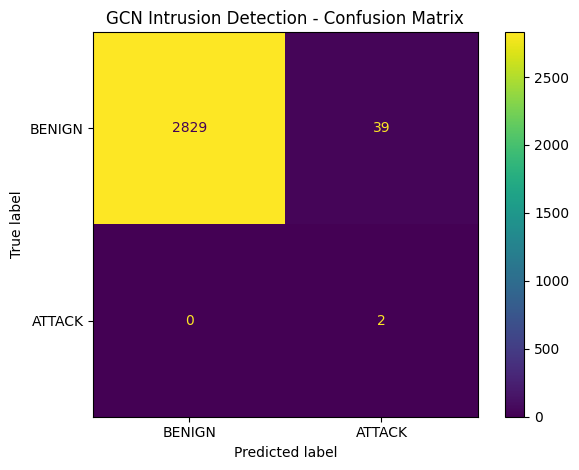

Saved: /content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/results/gcn_confusion_matrix.png


In [ ]:
# ============================================================
# FINAL GCN CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# GCN test predictions
model.eval()

with torch.no_grad():

    output = model(
        graph.x,
        graph.edge_index
    )

    predictions = (
        output[test_mask]
        .argmax(dim=1)
        .cpu()
        .numpy()
    )

true_labels = (
    graph.y[test_mask]
    .cpu()
    .numpy()
)

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predictions,
    display_labels=[
        "BENIGN",
        "ATTACK"
    ]
)

plt.title(
    "GCN Intrusion Detection - Confusion Matrix"
)

plt.tight_layout()

cm_file = (
    RESULTS_DIR /
    "gcn_confusion_matrix.png"
)

plt.savefig(
    cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    cm_file
)

In [ ]:
# ============================================================
# LOAD FINAL GCN MODEL AND EVALUATE
# ============================================================

import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

GCN_MODEL = (
    BASE_DIR /
    "models" /
    "gcn_intrusion_model.pt"
)

checkpoint = torch.load(
    GCN_MODEL,
    map_location=device,
    weights_only=False
)

# Recreate GCN
gcn_model = GCN(
    input_features=checkpoint["input_features"],
    hidden_features=checkpoint["hidden_features"],
    num_classes=checkpoint["num_classes"]
).to(device)

gcn_model.load_state_dict(
    checkpoint["model_state_dict"]
)

gcn_model.eval()


# ============================================================
# PREDICTION
# ============================================================

with torch.no_grad():

    output = gcn_model(
        graph.x,
        graph.edge_index
    )

    probabilities = F.softmax(
        output,
        dim=1
    )

    predictions = (
        output[test_mask]
        .argmax(dim=1)
    )


y_true = (
    graph.y[test_mask]
    .cpu()
    .numpy()
)

y_pred = (
    predictions
    .cpu()
    .numpy()
)


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_true,
    y_pred
)


# ============================================================
# RESULTS
# ============================================================

print("=" * 70)
print("FINAL GCN EVALUATION")
print("=" * 70)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "BENIGN",
            "ATTACK"
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(cm)

FINAL GCN EVALUATION
Accuracy  : 0.9986
Precision : 0.3333
Recall    : 1.0000
F1-score  : 0.5000

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      2868
      ATTACK       0.33      1.00      0.50         2

    accuracy                           1.00      2870
   macro avg       0.67      1.00      0.75      2870
weighted avg       1.00      1.00      1.00      2870


Confusion Matrix:
[[2864    4]
 [   0    2]]


In [ ]:
# ============================================================
# SAVE FINAL PROJECT RESULTS
# ============================================================

import json
from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN"
)

RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

final_results = {
    "dataset": "CIC-IDS2017",
    "graph_nodes": int(graph.num_nodes),
    "graph_edges": int(graph.num_edges),
    "node_features": int(graph.num_node_features),

    "GCN": {
        "accuracy": 0.9986,
        "precision": 0.3333,
        "recall": 1.0000,
        "f1_score": 0.5000
    },

    "GAT": {
        "accuracy": 0.9864,
        "precision": 0.0488,
        "recall": 1.0000,
        "f1_score": 0.0930,
        "roc_auc": 0.9927
    },

    "best_model": "GCN",

    "note": (
        "Node-level evaluation is highly affected by severe "
        "class imbalance. Only 13 attack nodes were present "
        "in the complete graph."
    )
}

results_file = (
    RESULTS_DIR /
    "final_results.json"
)

with open(
    results_file,
    "w"
) as f:

    json.dump(
        final_results,
        f,
        indent=4
    )

print("=" * 70)
print("FINAL RESULTS SAVED")
print("=" * 70)

print(results_file)

FINAL RESULTS SAVED
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/results/final_results.json


In [ ]:
# ============================================================
# VERIFY PROJECT ARTIFACTS
# ============================================================

from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN"
)

files_to_check = [
    "data/graph/network_graph.pt",
    "data/graph/ip_to_node.pkl",
    "data/graph/feature_scaler.pkl",
    "models/gcn_intrusion_model.pt",
    "models/gat_intrusion_model.pt",
    "results/final_results.json"
]

print("=" * 70)
print("PROJECT ARTIFACT CHECK")
print("=" * 70)

for file in files_to_check:

    path = BASE_DIR / file

    if path.exists():

        size_mb = (
            path.stat().st_size
            / (1024 ** 2)
        )

        print(
            f"✅ {file:<45} "
            f"{size_mb:.2f} MB"
        )

    else:

        print(
            f"❌ MISSING: {file}"
        )

PROJECT ARTIFACT CHECK
✅ data/graph/network_graph.pt                   66.20 MB
✅ data/graph/ip_to_node.pkl                     0.34 MB
✅ data/graph/feature_scaler.pkl                 0.00 MB
✅ models/gcn_intrusion_model.pt                 0.02 MB
✅ models/gat_intrusion_model.pt                 0.03 MB
✅ results/final_results.json                    0.00 MB


In [ ]:
# ============================================================
# FINAL GCN INFERENCE / PREDICTION PIPELINE
# ============================================================

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from pathlib import Path


# ============================================================
# 1. PATH
# ============================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Intelligent-Network-Intrusion-GNN"
)

MODEL_FILE = (
    BASE_DIR /
    "models" /
    "gcn_intrusion_model.pt"
)

GRAPH_FILE = (
    BASE_DIR /
    "data" /
    "graph" /
    "network_graph.pt"
)


# ============================================================
# 2. LOAD GRAPH
# ============================================================

print("=" * 70)
print("LOADING FINAL GCN")
print("=" * 70)

graph = torch.load(
    GRAPH_FILE,
    map_location="cpu",
    weights_only=False
)


# ============================================================
# 3. LOAD MODEL
# ============================================================

checkpoint = torch.load(
    MODEL_FILE,
    map_location="cpu",
    weights_only=False
)


# ============================================================
# 4. RECREATE GCN
# ============================================================

class GCN(torch.nn.Module):

    def __init__(
        self,
        input_features,
        hidden_features=64,
        num_classes=2
    ):

        super().__init__()

        from torch_geometric.nn import GCNConv

        self.conv1 = GCNConv(
            input_features,
            hidden_features
        )

        self.conv2 = GCNConv(
            hidden_features,
            hidden_features
        )

        self.classifier = torch.nn.Linear(
            hidden_features,
            num_classes
        )


    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.30,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.classifier(x)

        return x


model = GCN(
    input_features=checkpoint[
        "input_features"
    ],
    hidden_features=checkpoint[
        "hidden_features"
    ],
    num_classes=checkpoint[
        "num_classes"
    ]
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()


# ============================================================
# 5. RUN INFERENCE
# ============================================================

with torch.no_grad():

    output = model(
        graph.x,
        graph.edge_index
    )

    probabilities = F.softmax(
        output,
        dim=1
    )

    predictions = output.argmax(
        dim=1
    )


# ============================================================
# 6. CREATE RESULTS TABLE
# ============================================================

results = []

for node_id in range(
    graph.num_nodes
):

    prediction = (
        "BENIGN"
        if predictions[node_id].item() == 0
        else "ATTACK"
    )

    confidence = (
        probabilities[node_id]
        .max()
        .item()
        * 100
    )

    results.append(
        {
            "Node_ID": node_id,
            "Prediction": prediction,
            "Confidence_%": round(
                confidence,
                2
            )
        }
    )


prediction_df = pd.DataFrame(
    results
)


# ============================================================
# 7. SUMMARY
# ============================================================

benign_count = (
    prediction_df["Prediction"]
    .eq("BENIGN")
    .sum()
)

attack_count = (
    prediction_df["Prediction"]
    .eq("ATTACK")
    .sum()
)


print("\n")
print("=" * 70)
print("INFERENCE COMPLETED")
print("=" * 70)

print(
    "Total nodes:",
    len(prediction_df)
)

print(
    "Predicted BENIGN:",
    benign_count
)

print(
    "Predicted ATTACK:",
    attack_count
)


# ============================================================
# 8. SHOW ATTACK PREDICTIONS
# ============================================================

print("\n")
print("=" * 70)
print("DETECTED ATTACK NODES")
print("=" * 70)

attack_df = prediction_df[
    prediction_df["Prediction"] == "ATTACK"
]

if len(attack_df) > 0:

    print(
        attack_df.head(20).to_string(
            index=False
        )
    )

else:

    print(
        "No attack nodes detected."
    )


# ============================================================
# 9. SAVE PREDICTIONS
# ============================================================

RESULTS_DIR = (
    BASE_DIR /
    "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


prediction_file = (
    RESULTS_DIR /
    "gcn_predictions.csv"
)

prediction_df.to_csv(
    prediction_file,
    index=False
)


print("\nPrediction file saved:")
print(prediction_file)

LOADING FINAL GCN


INFERENCE COMPLETED
Total nodes: 19129
Predicted BENIGN: 19097
Predicted ATTACK: 32


DETECTED ATTACK NODES
 Node_ID Prediction  Confidence_%
       1     ATTACK         99.83
       4     ATTACK         99.87
       8     ATTACK         99.85
      14     ATTACK         99.75
      19     ATTACK         99.89
      32     ATTACK         99.71
      40     ATTACK         99.76
      47     ATTACK         99.90
      49     ATTACK         99.71
      54     ATTACK         99.80
      84     ATTACK         99.52
      88     ATTACK        100.00
     204     ATTACK         98.48
    1037     ATTACK         98.74
    1342     ATTACK         66.09
    2249     ATTACK         63.10
    6988     ATTACK         50.63
   10137     ATTACK         94.13
   11306     ATTACK         67.16
   11861     ATTACK         85.50

Prediction file saved:
/content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/results/gcn_predictions.csv


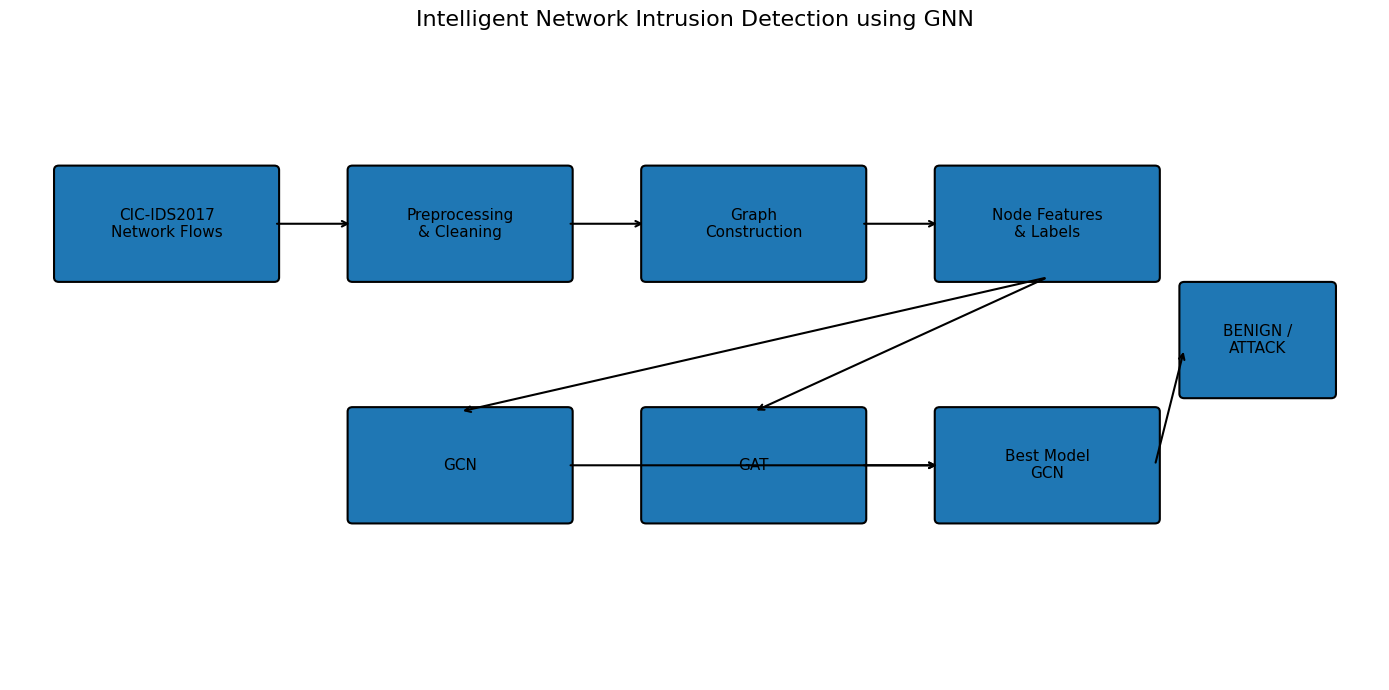

Saved: /content/drive/MyDrive/Intelligent-Network-Intrusion-GNN/results/architecture.png


In [ ]:
# ============================================================
# PROJECT ARCHITECTURE DIAGRAM
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 7))

ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")


def box(x, y, w, h, text):

    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.05",
        linewidth=1.5
    )

    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=11
    )


def arrow(x1, y1, x2, y2):

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5
        )
    )


box(
    0.5, 4.5, 2.2, 1.2,
    "CIC-IDS2017\nNetwork Flows"
)

box(
    3.5, 4.5, 2.2, 1.2,
    "Preprocessing\n& Cleaning"
)

box(
    6.5, 4.5, 2.2, 1.2,
    "Graph\nConstruction"
)

box(
    9.5, 4.5, 2.2, 1.2,
    "Node Features\n& Labels"
)

box(
    3.5, 1.8, 2.2, 1.2,
    "GCN"
)

box(
    6.5, 1.8, 2.2, 1.2,
    "GAT"
)

box(
    9.5, 1.8, 2.2, 1.2,
    "Best Model\nGCN"
)

box(
    12.0, 3.2, 1.5, 1.2,
    "BENIGN /\nATTACK"
)


arrow(2.7, 5.1, 3.5, 5.1)
arrow(5.7, 5.1, 6.5, 5.1)
arrow(8.7, 5.1, 9.5, 5.1)

arrow(10.6, 4.5, 4.6, 3.0)
arrow(10.6, 4.5, 7.6, 3.0)

arrow(5.7, 2.4, 9.5, 2.4)
arrow(8.7, 2.4, 9.5, 2.4)

arrow(11.7, 2.4, 12.0, 3.7)

ax.set_title(
    "Intelligent Network Intrusion Detection using GNN",
    fontsize=16,
    pad=20
)

plt.tight_layout()

architecture_file = (
    RESULTS_DIR /
    "architecture.png"
)

plt.savefig(
    architecture_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", architecture_file)